# KHUDA 9기 파이썬 세션 - 영화 흥행 예측 프로젝트

## 2026.02.19(목)

# KHUDA 9기 파이썬 세션 실습

## 오늘 할 일

1. 데이터 로드&분리
2. 스케일링
3. 피처 엔지니어링
4. 모델 학습
5. 예측 및 평가
6. 하이퍼파라미터 튜닝

## Step 0: 라이브러리 불러오기

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


---
## Step 1: 데이터 로드 & 분리

### 1-1. 데이터 로드

In [5]:
url = 'https://raw.githubusercontent.com/kwang-i-coder/KHUDA-9th-Python/main/week3/tmdb_5000_movies.csv'
df = pd.read_csv(url)

selected_cols = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue']
df = df[selected_cols]

df = df.dropna()
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

print(f"데이터 준비 완료! 총 {len(df)}개의 영화 데이터")
print(f"사용 가능한 컬럼: {df.columns.tolist()}")
display(df.head())

데이터 준비 완료! 총 3229개의 영화 데이터
사용 가능한 컬럼: ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue']


,budget,popularity,runtime,vote_average,vote_count,revenue
0,237000000,150.437577,162.0,7.2,11800,2787965087
1,300000000,139.082615,169.0,6.9,4500,961000000
2,245000000,107.376788,148.0,6.3,4466,880674609
3,250000000,112.312950,165.0,7.6,9106,1084939099
4,260000000,43.926995,132.0,6.1,2124,284139100


### 1-2. X(특성)와 y(타겟) 분리

우리가 **예측하고 싶은 것**: `revenue` (흥행 수익)

우리가 **사용할 특성**: `budget`, `popularity`, `runtime`, `vote_average`

In [7]:
# TODO X(특성)와 y(타겟)를 분리하세요
# X에는 budget, popularity, runtime, vote_average 컬럼을 사용하세요
# y에는 revenue 컬럼을 사용하세요

features = ['budget', 'popularity', 'runtime', 'vote_average']

X = df[features]
y = df['revenue']

print(f'X 크기: {X.shape}')
print(f'y 크기: {y.shape}')
print(f'\nX 미리보기:')
X.head(3)

X 크기: (3229, 4)
y 크기: (3229,)

X 미리보기:


,budget,popularity,runtime,vote_average
0,237000000,150.437577,162.0,7.2
1,300000000,139.082615,169.0,6.9
2,245000000,107.376788,148.0,6.3


<details>
<summary> 힌트 (클릭해서 열기)</summary>

```python
X = df[features]   # 여러 컬럼 선택
y = df['revenue']  # 타겟 컬럼
```
</details>

### 1-3. Train / Test 분리

In [8]:
# TODO train_test_split으로 데이터를 8:2로 분리하세요

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'훈련 데이터: {X_train.shape}')
print(f'테스트 데이터: {X_test.shape}')
print(f'\n훈련 비율: {len(X_train)/len(X)*100:.1f}%')
print(f'테스트 비율: {len(X_test)/len(X)*100:.1f}%')

훈련 데이터: (2583, 4)
테스트 데이터: (646, 4)

훈련 비율: 80.0%
테스트 비율: 20.0%


<details>
<summary>힌트 (클릭해서 열기)</summary>

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```
</details>

## Step 2: 스케일링

In [9]:
# TODO StandardScaler를 생성하고 훈련 데이터에 fit_transform, 테스트 데이터에 transform 적용

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('스케일링 전 budget 평균:', X_train['budget'].mean())
print('스케일링 후 budget 평균:', X_train_scaled[:, 0].mean().round(4))
print('\n스케일링 완료!')

스케일링 전 budget 평균: 39670873.83933411
스케일링 후 budget 평균: 0.0

스케일링 완료!


<details>
<summary>힌트 (클릭해서 열기)</summary>

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit 없이 transform만!
```

---
## Step 3: 피처 엔지니어링

기존 컬럼들을 조합해서 **새로운 변수**를 만들어봅시다!

[HINT] 어떤 변수를 만들지 막막한가요?

가성비: 예산 대비 수익률 (revenue / budget) -> 단, revenue는 타겟이라 사용 불가!

제작 효율: 분당 제작비 (budget / runtime)

투표 파급력: 평점 * 투표수 (vote_average * vote_count)

개봉 계절: release_date에서 월(month)만 뽑아서 봄/여름/가을/겨울 구분

### 미션: 본인만의 파생변수를 최소 2개 만들어보세요!

In [10]:
# 원본 데이터 복사 (원본 훼손 방지)
df_fe = df.copy()

# 예시: 제공된 파생변수 1개
df_fe['budget_per_minute'] = df_fe['budget'] / (df_fe['runtime'] + 1)  # 분당 예산


# TODO 파생변수를 2개 이상 직접 만들어보세요!
# 아이디어:
# - popularity와 vote_average를 곱하면? (인기 × 평점)
# - budget이 1억 이상이면 1, 아니면 0 (대작 여부)
# - 본인만의 아이디어!

df_fe['vote'] = df_fe['popularity'] * df_fe['vote_average']
df_fe['is_blockbuster'] = df_fe['budget'].apply(lambda x: 1 if x >= 100000000 else 0)

print('새로 만든 컬럼들:')
new_cols = [col for col in df_fe.columns if col not in df.columns]
print(new_cols)
df_fe[new_cols].describe()

새로 만든 컬럼들:
['budget_per_minute', 'vote', 'is_blockbuster']


,budget_per_minute,vote,is_blockbuster
count,3.229000e+03,3229.000000,3229.000000
mean,3.589923e+05,192.251397,0.098483
std,3.757813e+05,261.627307,0.298012
min,1.136364e-02,0.000000,0.000000
25%,1.000000e+05,61.543296,0.000000
50%,2.358491e+05,128.677631,0.000000
75%,4.854369e+05,242.592012,0.000000
max,2.773723e+06,5866.407050,1.000000


In [11]:
# TODO 새로운 피처를 포함한 X, y 다시 만들기
# 방금 만든 파생변수도 추가하세요!

features = ['budget', 'popularity', 'runtime', 'vote_average',
               'vote_count',
               'vote',   # 내가 만든 변수 1
               'is_blockbuster']   # 내가 만든 변수 2

X = df_fe[features]
y = df_fe['revenue']

X2_train, X2_test, y2_train, y2_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)

print(f'피처 수: {len(features)}개')
print(f'피처 목록: {features}')

피처 수: 7개
피처 목록: ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'vote', 'is_blockbuster']


---
## Step 4: 모델 학습 

### 4-1. Linear Regression

In [12]:
# TODO Linear Regression 모델 학습

lr_model = LinearRegression()
lr_model.fit(X2_train_scaled, y2_train)
lr_pred = lr_model.predict(X2_test_scaled)

print('Linear Regression 학습 완료!')
print(f'첫 번째 예측값: ${lr_pred[0]:,.0f}')
print(f'실제값: ${y_test.iloc[0]:,.0f}')

Linear Regression 학습 완료!
첫 번째 예측값: $156,362,215
실제값: $169,852,759


<details>
<summary>힌트 (클릭해서 열기)</summary>

```python
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
```
</details>

### 4-2. Random Forest Regressor

In [13]:
# TODO Random Forest 모델 학습
# RandomForestRegressor(n_estimators=100, random_state=42) 사용

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y2_train)
rf_pred = rf_model.predict(X_test_scaled)

print('Random Forest 학습 완료!')
print(f'트리 개수: {rf_model.n_estimators}개')

Random Forest 학습 완료!
트리 개수: 100개


<details>
<summary>힌트 (클릭해서 열기)</summary>

```python
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
```
</details>

---
## Step 5: 예측 및 평가

In [16]:
# TODO 두 모델의 평가 지표를 계산하세요

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f'\n[{name}]')
    print(f'  RMSE: ${rmse:,.0f}')
    print(f'  MAE:  ${mae:,.0f}')
    print(f'  R²:   {r2:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = {}
results['Linear Regression'] = evaluate_model('Linear Regression', y_test, lr_pred)
results['Random Forest']     = evaluate_model('Random Forest',     y_test, rf_pred)


[Linear Regression]
  RMSE: $131,298,295
  MAE:  $65,680,569
  R²:   0.6589

[Random Forest]
  RMSE: $133,775,215
  MAE:  $67,224,852
  R²:   0.6459


<details>
<summary>힌트 (클릭해서 열기)</summary>

```python
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
```
</details>

/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/3616878204.py:15: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/3616878204.py:15: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/3616878204.py:15: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/3616878204.py:15: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/3616878204.py:15: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipyk

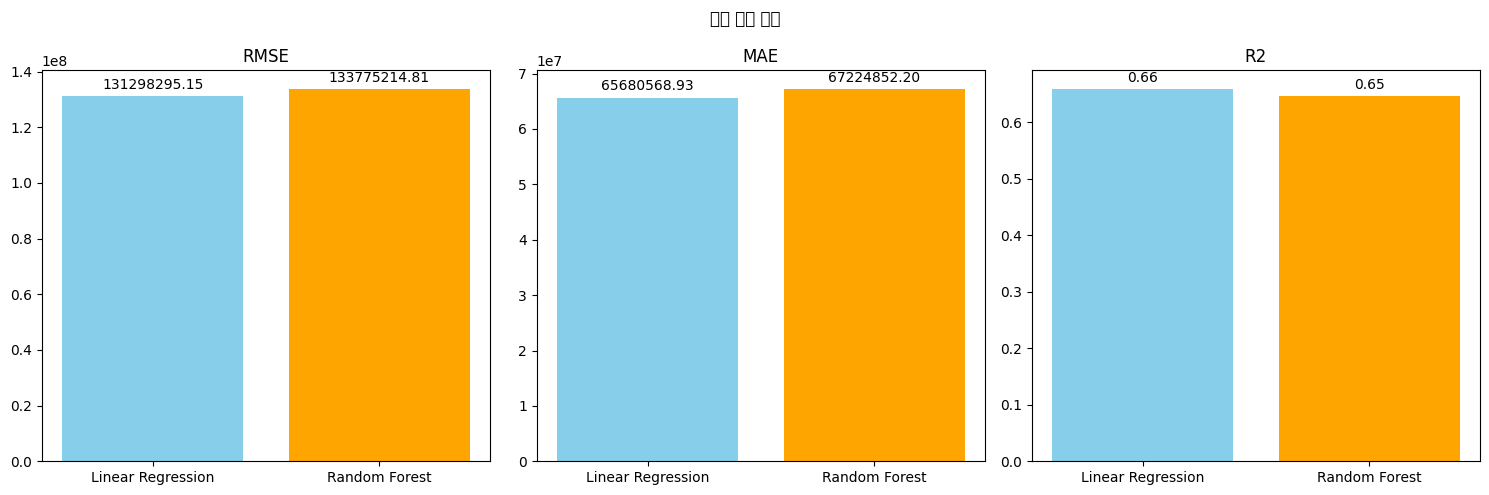

In [17]:
# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('모델 성능 비교')

metrics = ['RMSE', 'MAE', 'R2']
models = list(results.keys())

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in models]
    bars = axes[i].bar(models, values, color=['skyblue', 'orange'])
    
    axes[i].set_title(metric)
    axes[i].bar_label(bars, padding=3, fmt='%.2f') 

plt.tight_layout()
plt.show()

/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/2237494828.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/2237494828.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/2237494828.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/2237494828.py:21: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipykernel_24649/2237494828.py:21: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4q/wdjpb29s08j54337b1j7xd040000gn/T/ipyker

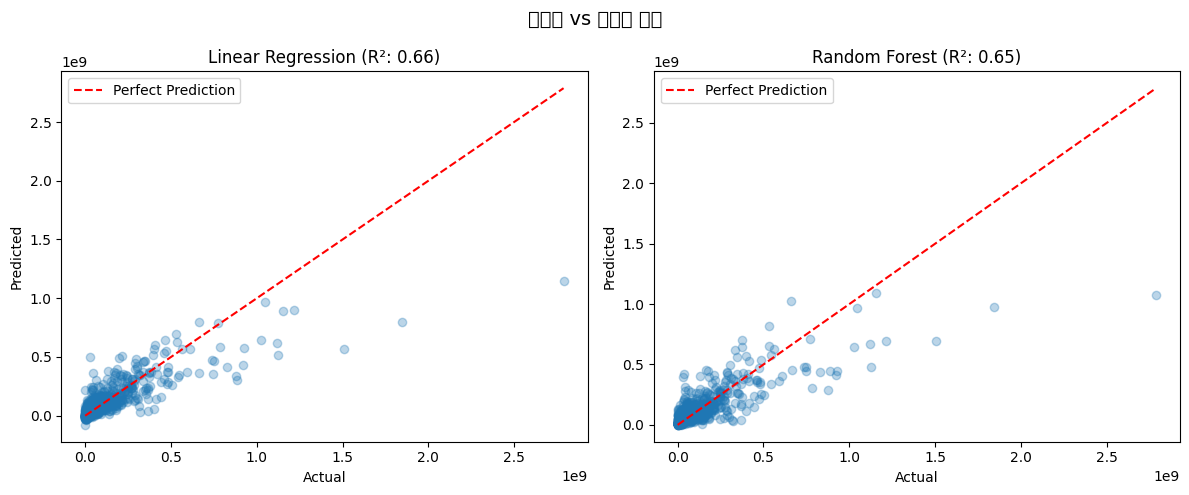

In [18]:
# TODO: 예측값 vs 실제값 산점도 그리기
# x축: y_test (실제값), y축: 각 모델의 예측값
# 대각선(y=x)에 가까울수록 좋은 모델입니다!

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pred) in zip(axes, [('Linear Regression', lr_pred), ('Random Forest', rf_pred)]):
    # 산점도 그리기 (실제값, 예측값 순서로 넣어보세요)
    ax.scatter(y_test, pred, alpha=0.3)
    
    # 기준 대각선 그리기 (힌트: 실제값의 최소값과 최대값을 이어보세요)
    # ax.plot([x1, x2], [y1, y2], ...) 형태입니다.
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    
    ax.set_title(f'{name} (R²: {r2_score(y_test, pred):.2f})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.suptitle('예측값 vs 실제값 비교', fontsize=14)
plt.tight_layout()
plt.show()

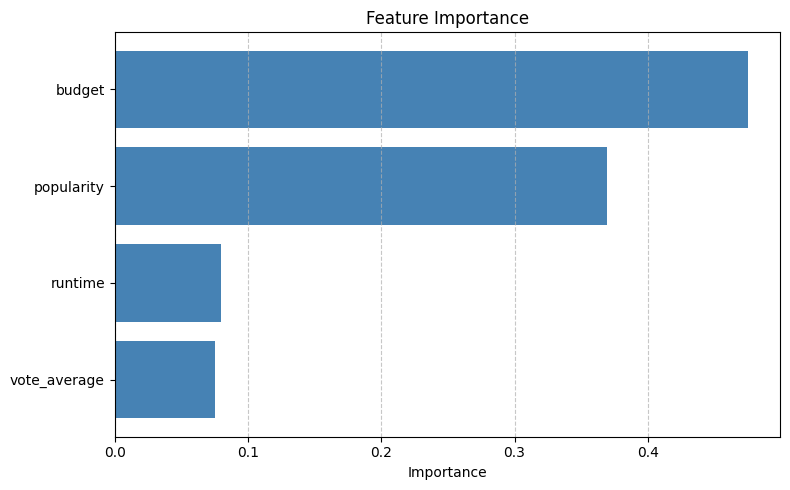


가장 중요한 피처: budget
왜 budget 변수가 예측에 가장 큰 영향을 주었을까요?


In [19]:
# 어떤 특성이 예측에 가장 기여했는가?

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['feature'], feat_df['importance'], color='steelblue')

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

top_feature = feat_df.iloc[-1]['feature']
print(f'\n가장 중요한 피처: {top_feature}')
print(f'왜 {top_feature} 변수가 예측에 가장 큰 영향을 주었을까요?')

---
## Step 6: 하이퍼파라미터 튜닝

### 파라미터를 바꿔서 더 좋은 R²를 만들어보세요!

In [20]:
# TODO 파라미터를 직접 바꿔가면서 최고의 조합을 찾아보세요
# n_estimators, max_depth, min_samples_split 중 하나 이상 수정해보세요

rf_tuned = RandomForestRegressor(
    n_estimators=200,      # 시도: 50, 100, 200, 500
    max_depth=None,         # 시도: 5, 10, 20, None
    min_samples_split=5, # 시도: 2, 5, 10
    random_state=42
)

rf_tuned.fit(X_train_scaled, y_train)
rf_tuned_pred = rf_tuned.predict(X_test_scaled)

r2_before = r2_score(y_test, rf_pred)
r2_after  = r2_score(y_test, rf_tuned_pred)

print(f'튜닝 전 R²: {r2_before:.4f}')
print(f'튜닝 후 R²: {r2_after:.4f}')
print(f'변화: {(r2_after - r2_before):+.4f} {"개선!" if r2_after > r2_before else "성능 저하"}')

튜닝 전 R²: 0.6459
튜닝 후 R²: 0.6507
변화: +0.0047 개선!


In [21]:
# TODO 피처 엔지니어링 + 튜닝 조합으로 최고 성능 도전!
# 앞에서 만든 X2_train_scaled, X2_test_scaled를 사용해보세요

rf_best = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

rf_best.fit(X2_train_scaled, y2_train)
rf_best_pred = rf_best.predict(X2_test_scaled)

print(f'기본 모델 R²:         {r2_score(y_test, lr_pred):.4f}  (Linear Regression)')
print(f'Random Forest R²:     {r2_score(y_test, rf_pred):.4f}')
print(f'튜닝 후 R²:           {r2_score(y_test, rf_tuned_pred):.4f}')
print(f'피처 엔지 + 튜닝 R²:  {r2_score(y2_test, rf_best_pred):.4f}  ← 최고?')

기본 모델 R²:         0.6589  (Linear Regression)
Random Forest R²:     0.6459
튜닝 후 R²:           0.6507
피처 엔지 + 튜닝 R²:  0.7131  ← 최고?


## 최종 결과 정리

In [22]:
# 최종 결과 요약

# 점수 비교를 위한 데이터 모으기
final_summary = {
    '1. 선형 회귀 (기본)': r2_score(y_test, lr_pred),
    '2. 랜덤 포레스트 (기본)': r2_score(y_test, rf_pred),
    '3. 랜덤 포레스트 (최종)': r2_score(y_test, rf_best_pred) # 보너스 단계
}

print("-" * 30)
print("   [ 모델별 성능 결과 ]")
print("-" * 30)

for name, r2 in final_summary.items():
    print(f"{name}: R² = {r2:.4f}")

best_name = max(final_summary, key=final_summary.get)
print("-" * 30)
print(f"최고 성능: {best_name} ({final_summary[best_name]:.4f})")
print("-" * 30)

------------------------------
   [ 모델별 성능 결과 ]
------------------------------
1. 선형 회귀 (기본): R² = 0.6589
2. 랜덤 포레스트 (기본): R² = 0.6459
3. 랜덤 포레스트 (최종): R² = 0.7131
------------------------------
최고 성능: 3. 랜덤 포레스트 (최종) (0.7131)
------------------------------
